# Análisis de accidentes fatales – Pereira (2023–2025)

Notebook organizado (OOP) para: carga → limpieza → EDA → mapas → modelo predictivo.

**Archivo de entrada:** `Fatales Pereira 2023-2025 2.xlsx` (hoja `BASE`).


In [1]:
# ✅ Instalación (solo Colab). En Windows ejecuta en tu entorno con pip.
# Si ya instalaste, puedes omitir esta celda.
#!pip -q install pandas numpy seaborn matplotlib scikit-learn folium openpyxl


In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import folium

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, f1_score
from sklearn.ensemble import RandomForestClassifier

from IPython.display import IFrame, display

plt.rcParams["figure.dpi"] = 110


## 1) Configuración

Ajusta `FILE_PATH` si lo guardas en Drive.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# En Colab (archivo subido al panel de archivos):
FILE_PATH = "/content/Fatales Pereira 2023-2025 2.xlsx"
SHEET_NAME = "BASE"

# Si lo guardas en Drive:
# from google.colab import drive
# drive.mount('/content/drive')
#FILE_PATH = "/content/drive/MyDrive/TU_CARPETA/Fatales Pereira 2023-2025 2.xlsx"


## 2) Clases (OOP)

Una sola definición por clase (sin duplicados).

In [5]:
class DataLoader:
    def __init__(self, file_path: str, sheet_name: str = "BASE"):
        self.file_path = file_path
        self.sheet_name = sheet_name

    def load(self) -> pd.DataFrame:
        if not os.path.exists(self.file_path):
            raise FileNotFoundError(
                f"No se encontró el archivo en: {self.file_path}\n"
                "👉 En Colab: súbelo a /content o monta Drive."
            )

        df = pd.read_excel(self.file_path, sheet_name=self.sheet_name)
        # Normalización leve de nombres (conserva paréntesis porque tu base los usa)
        df.columns = (
            df.columns.astype(str).str.strip().str.lower()
            .str.replace(" ", "_")
            .str.replace("á", "a").str.replace("é", "e")
            .str.replace("í", "i").str.replace("ó", "o")
            .str.replace("ú", "u").str.replace("ñ", "n")
        )
        print(f"✅ Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
        return df


class DataCleaner:
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()

    @staticmethod
    def _clean_text(s: pd.Series) -> pd.Series:
        s = s.astype("string").str.strip().str.replace(r"\s+", " ", regex=True).str.upper()
        s = s.replace({
            "NO APLICA": pd.NA,
            "NO DILIGENCIADO": pd.NA,
            "SIN INFORMACIÓN": pd.NA,
            "SIN INFORMACION": pd.NA,
            "NS/NR - SIN INFORMACIÓN": pd.NA,
            "NS/NR - SIN INFORMACION": pd.NA,
            "": pd.NA
        })
        return s

    def clean_types(self):
        # numéricas frecuentes
        for col in ["edad_calculada_en_anos", "latitude", "longitude"]:
            if col in self.df.columns:
                self.df[col] = pd.to_numeric(self.df[col], errors="coerce")

        # fechas
        if "fecha_del_hecho" in self.df.columns:
            self.df["fecha_del_hecho"] = pd.to_datetime(self.df["fecha_del_hecho"], errors="coerce")

        # hora de reporte -> hora 0-23
        if "hora_de_los_hechos(reporte)" in self.df.columns:
            col = "hora_de_los_hechos(reporte)"
            s = self.df[col].astype("string").str.strip()

            # intenta HH:MM:SS, si falla intenta HH:MM
            dt = pd.to_datetime(s, format="%H:%M:%S", errors="coerce")
            dt2 = pd.to_datetime(s, format="%H:%M", errors="coerce")

            self.df["hora_reporte_dt"] = dt.fillna(dt2)
            self.df["hora_reporte"] = self.df["hora_reporte_dt"].dt.hour

        # limpieza de texto en columnas clave
        for col in ["vehiculo", "clase_de_siniestro", "zona_del_hecho", "objeto_de_colision", "sexo", "condicion_de_la_victima"]:
            if col in self.df.columns:
                self.df[col] = self._clean_text(self.df[col])

        return self

    def build_time_features(self):
        if "fecha_del_hecho" in self.df.columns:
            self.df["anio"] = self.df["fecha_del_hecho"].dt.year
            self.df["mes"] = self.df["fecha_del_hecho"].dt.month
            self.df["dia_semana"] = self.df["fecha_del_hecho"].dt.dayofweek
        return self

    def clean_target_classes(self, target_col="clase_de_siniestro"):
        # Eliminar categorías sin información y agrupar raras
        if target_col in self.df.columns:
            self.df = self.df[~self.df[target_col].isin(["NS/NR - SIN INFORMACIÓN", "NO DILIGENCIADO"])].copy()
            self.df[target_col] = self.df[target_col].replace({
                "CAIDA DEL OCUPANTE": "OTROS",
                "VOLCAMIENTO": "OTROS"
            })
        return self

    def get_df(self) -> pd.DataFrame:
        return self.df


class EDA:
    def __init__(self, df: pd.DataFrame):
        self.df = df

    def missing_top(self, n=15):
        plt.figure(figsize=(10, 5))
        self.df.isna().mean().sort_values(ascending=False).head(n).plot(kind="bar")
        plt.title(f"Top {n} columnas con mayor proporción de nulos")
        plt.ylabel("Proporción de nulos")
        plt.tight_layout()
        plt.show()

    def plot_hour(self):
        if "hora_reporte" not in self.df.columns:
            print("⚠️ No existe 'hora_reporte'. Verifica la columna de hora.")
            return
        plt.figure(figsize=(12, 5))
        sns.countplot(x="hora_reporte", data=self.df)
        plt.title("Accidentes por hora del día (hora de los hechos - reporte)")
        plt.xlabel("Hora")
        plt.ylabel("Número de accidentes")
        plt.xticks(range(0, 24))
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_vehicle_top(self, top_n=15):
        if "vehiculo" not in self.df.columns:
            print("⚠️ No existe 'vehiculo'.")
            return
        counts = self.df["vehiculo"].dropna().value_counts().head(top_n)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=counts.values, y=counts.index)
        plt.title(f"Accidentes fatales por tipo de vehículo (Top {top_n})")
        plt.xlabel("Número de accidentes fatales")
        plt.ylabel("Tipo de vehículo")
        plt.grid(axis="x", alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_siniestro_top(self, top_n=10):
        if "clase_de_siniestro" not in self.df.columns:
            print("⚠️ No existe 'clase_de_siniestro'.")
            return
        counts = self.df["clase_de_siniestro"].dropna().value_counts().head(top_n)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=counts.values, y=counts.index)
        plt.title(f"Accidentes fatales por clase de siniestro (Top {top_n})")
        plt.xlabel("Número de accidentes fatales")
        plt.ylabel("Clase de siniestro")
        plt.grid(axis="x", alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_Vitima_top(self, top_n=10):
        if "condicion_de_la_victima" not in self.df.columns:
            print("⚠️ No existe 'condicion_de_la_victima'.")
            return
        counts = self.df["condicion_de_la_victima"].dropna().value_counts().head(top_n)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=counts.values, y=counts.index)
        plt.title(f"Accidentes fatales por Condicion de la victima (Top {top_n})")
        plt.xlabel("Número de accidentes fatales")
        plt.ylabel("Condicion de victima")
        plt.grid(axis="x", alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_siniestro_by_vehicle(self, top_veh=3):
        if "vehiculo" not in self.df.columns or "clase_de_siniestro" not in self.df.columns:
            print("⚠️ Faltan columnas 'vehiculo' o 'clase_de_siniestro'.")
            return
        top = self.df["vehiculo"].value_counts().head(top_veh).index
        d = self.df[self.df["vehiculo"].isin(top)].copy()
        plt.figure(figsize=(12, 6))
        sns.countplot(
            data=d, y="clase_de_siniestro", hue="vehiculo",
            order=d["clase_de_siniestro"].value_counts().index
        )
        plt.title(f"Clase de siniestro por tipo de vehículo (Top {top_veh})")
        plt.xlabel("Número de accidentes fatales")
        plt.ylabel("Clase de siniestro")
        plt.tight_layout()
        plt.show()


class MapVisualizer:
    def __init__(self, df, lat_col="latitude", lon_col="longitude"):
        self.df = df.copy()
        self.lat_col = lat_col
        self.lon_col = lon_col

    def create_map(
        self,
        output_html="mapa_accidentes.html",
        decimals=5,              # 5 ≈ 1.1 m, 4 ≈ 11 m (aprox)
        min_radius=4,            # radio mínimo del punto
        max_radius=28,           # radio máximo del punto
        scale="sqrt",            # "sqrt" o "linear"
        zoom_start=13
    ):
        df = self.df.copy()

        # 1) Limpiar lat/lon
        df = df.dropna(subset=[self.lat_col, self.lon_col])
        df = df[(df[self.lat_col].between(-90, 90)) & (df[self.lon_col].between(-180, 180))]

        # 2) Agrupar por punto (redondeando para “mismo sitio”)
        df["_lat_r"] = df[self.lat_col].round(decimals)
        df["_lon_r"] = df[self.lon_col].round(decimals)

        grouped = (
            df.groupby(["_lat_r", "_lon_r"])
              .size()
              .reset_index(name="accidentes")
              .rename(columns={"_lat_r": "lat", "_lon_r": "lon"})
        )

        # 3) Centro del mapa
        center_lat = grouped["lat"].mean()
        center_lon = grouped["lon"].mean()
        m = folium.Map(location=[center_lat, center_lon], zoom_start=zoom_start, control_scale=True)

        # 4) Escalado del radio según cantidad
        counts = grouped["accidentes"].to_numpy()
        cmin, cmax = counts.min(), counts.max()

        def radius_from_count(c):
            if cmax == cmin:
                return (min_radius + max_radius) / 2

            if scale == "linear":
                x = (c - cmin) / (cmax - cmin)
            else:  # sqrt (recomendado)
                x = (np.sqrt(c) - np.sqrt(cmin)) / (np.sqrt(cmax) - np.sqrt(cmin))

            return min_radius + x * (max_radius - min_radius)

        # 5) Dibujar puntos (uno por “sitio”)
        for _, r in grouped.iterrows():
            r_count = int(r["accidentes"])
            rad = float(radius_from_count(r_count))

            folium.CircleMarker(
                location=[r["lat"], r["lon"]],
                radius=rad,
                color="red",
                fill=True,
                fill_color="red",
                fill_opacity=0.55,
                weight=1,
                tooltip=f"Accidentes en este punto: {r_count}"
            ).add_to(m)

        m.save(output_html)
        print(f"🗺️ Mapa guardado en: {output_html}")
        display(m)
        display(IFrame(output_html, width=1000, height=650))
        return m


class PredictiveModel:
    def __init__(self, df: pd.DataFrame, target: str, min_samples_per_class: int = 5):
        self.df = df
        self.target = target
        self.min_samples_per_class = min_samples_per_class

    def train(self):
        features = [c for c in [
            "edad_calculada_en_anos",
            "sexo",
            "vehiculo",
            "objeto_de_colision",
            "zona_del_hecho",
            "anio",
            "mes",
            "dia_semana",
            "hora_reporte"
        ] if c in self.df.columns]

        # ✅ Copiar + convertir pd.NA -> np.nan (evita error sklearn)
        data = self.df[features + [self.target]].copy()

        # 1) Forzar a object (evita StringDtype que conserva <NA>)
        data = data.astype("object")

        # 2) Donde haya NA (pd.NA, NaT, etc.), dejar np.nan
        data = data.where(pd.notna(data), np.nan)

        # ✅ Quitar filas sin target
        data = data.dropna(subset=[self.target]).copy()

        # ✅ Convertir categóricas a object (sklearn más estable que string[python])
        for col in ["sexo", "vehiculo", "objeto_de_colision", "zona_del_hecho", self.target]:
            if col in data.columns:
                data[col] = data[col].astype("object")

        # Filtrar clases raras (para que stratify no falle)
        counts = data[self.target].value_counts()
        valid_classes = counts[counts >= self.min_samples_per_class].index
        data = data[data[self.target].isin(valid_classes)].copy()

        print("📌 Clases usadas en el modelo:")
        print(data[self.target].value_counts())

        X = data[features].copy()
        y = data[self.target].copy()

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )

        num_features = X.select_dtypes(include=["number"]).columns.tolist()
        cat_features = [c for c in X.columns if c not in num_features]

        preprocessor = ColumnTransformer([
            ("num", SimpleImputer(strategy="median"), num_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_features)
        ])

        model = RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        )

        pipe = Pipeline([
            ("preprocess", preprocessor),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        print("\n📊 Reporte de clasificación:")
        print(classification_report(y_test, y_pred))
        print("🎯 F1 macro:", f1_score(y_test, y_pred, average="macro"))

        return pipe

## 3) Carga y limpieza

In [6]:
loader = DataLoader(FILE_PATH, SHEET_NAME)
df = loader.load()

cleaner = (DataCleaner(df)
           .clean_types()
           .build_time_features()
           .clean_target_classes(target_col="clase_de_siniestro"))

df_clean = cleaner.get_df()

df_clean.head()


✅ Dataset cargado: 304 filas, 51 columnas


,id,regional,seccional,unidad_basica,departamento_de_atencion,municipio_de_atencion,numero_de_radicado,tipo_de_caso,sexo,edad_calculada_en_anos,...,objeto_de_colision,servicio_objeto_de_colision,vehiculo_fantasma,condicion_del_lugar_del_at,estado_de_la_via_at,hora_reporte_dt,hora_reporte,anio,mes,dia_semana
0,4496,Dirección regional occidente,Dirección seccional Risaralda,CARTAGO,VALLE DEL CAUCA,CARTAGO,2023010176147000241,NECROPSIA,FEMENINO,63.0,...,<NA>,NO APLICA,NO ES UN CARRO FANTASMA,NS / NR Ó SIN INFORMACIÓN,SIN INFORMACIÓN,1900-01-01 17:30:00,17.0,2023,11,2
1,5110,Dirección regional occidente,Dirección seccional Risaralda,PEREIRA,RISARALDA,PEREIRA,2023010166001000002,NECROPSIA,MASCULINO,51.0,...,OBJETO FIJO,NO APLICA,NO ES UN CARRO FANTASMA,NORMAL,BUENO,1900-01-01 05:07:00,5.0,2023,1,6
2,5113,Dirección regional occidente,Dirección seccional Risaralda,PEREIRA,RISARALDA,PEREIRA,2023010166001000005,NECROPSIA,MASCULINO,62.0,...,MOTOCICLETA,PARTICULAR,NO ES UN CARRO FANTASMA,NS / NR Ó SIN INFORMACIÓN,SIN INFORMACIÓN,1900-01-01 14:30:00,14.0,2023,1,1
3,5134,Dirección regional occidente,Dirección seccional Risaralda,PEREIRA,RISARALDA,PEREIRA,2023010166001000026,NECROPSIA,MASCULINO,69.0,...,AUTOMÓVIL,PARTICULAR,NO ES UN CARRO FANTASMA,NS / NR Ó SIN INFORMACIÓN,SIN INFORMACIÓN,1900-01-01 20:57:00,20.0,2023,1,0
4,5137,Dirección regional occidente,Dirección seccional Risaralda,PEREIRA,RISARALDA,PEREIRA,2023010166001000029,NECROPSIA,FEMENINO,33.0,...,AUTOMÓVIL,PARTICULAR,NO ES UN CARRO FANTASMA,NORMAL,BUENO,1900-01-01 22:30:00,22.0,2023,1,2


## 4) EDA (gráficas)

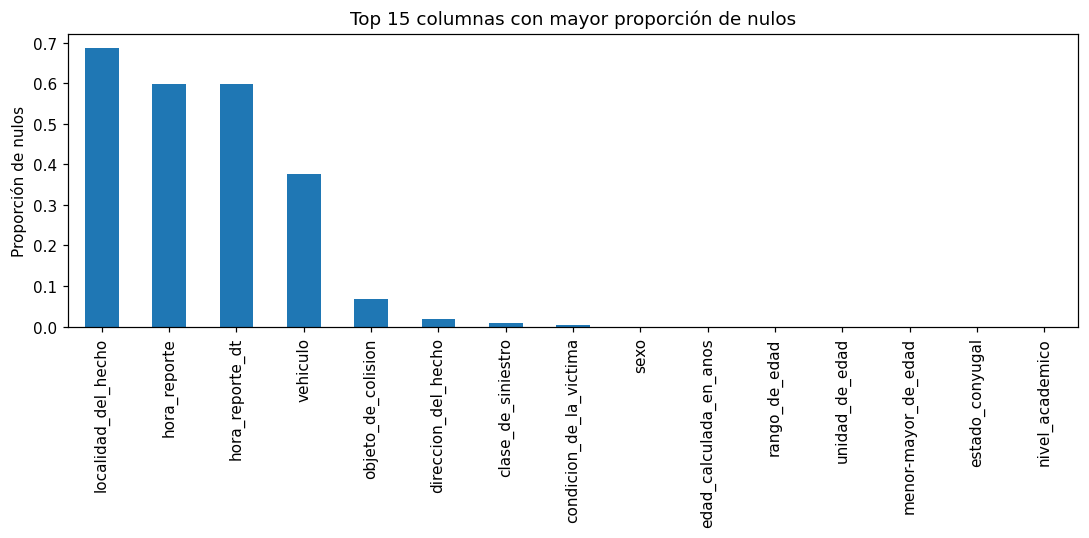

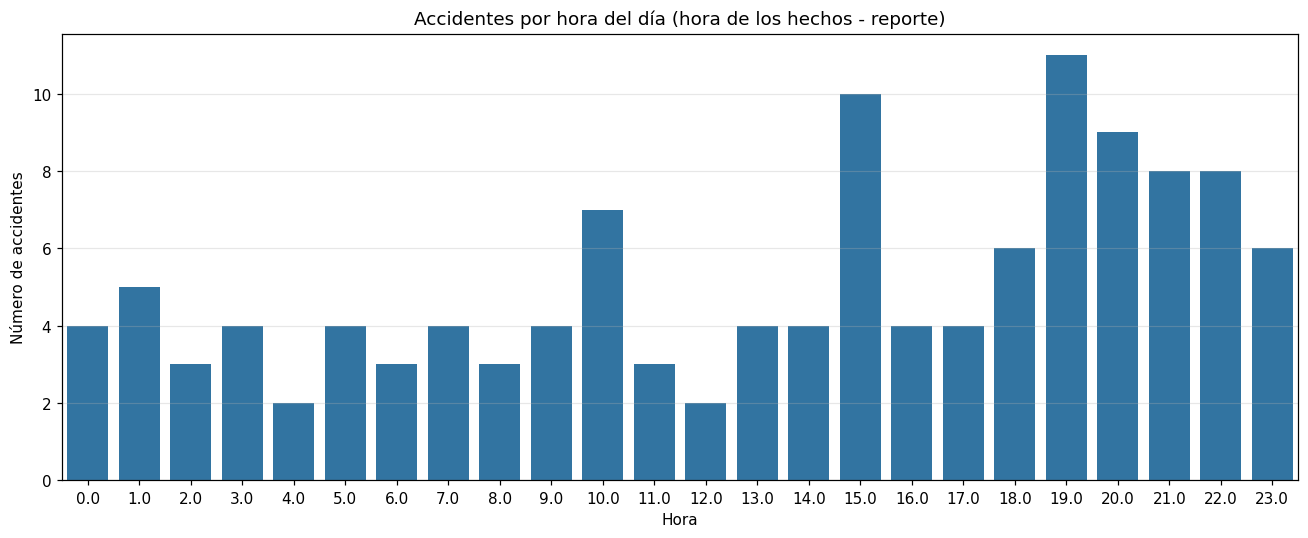

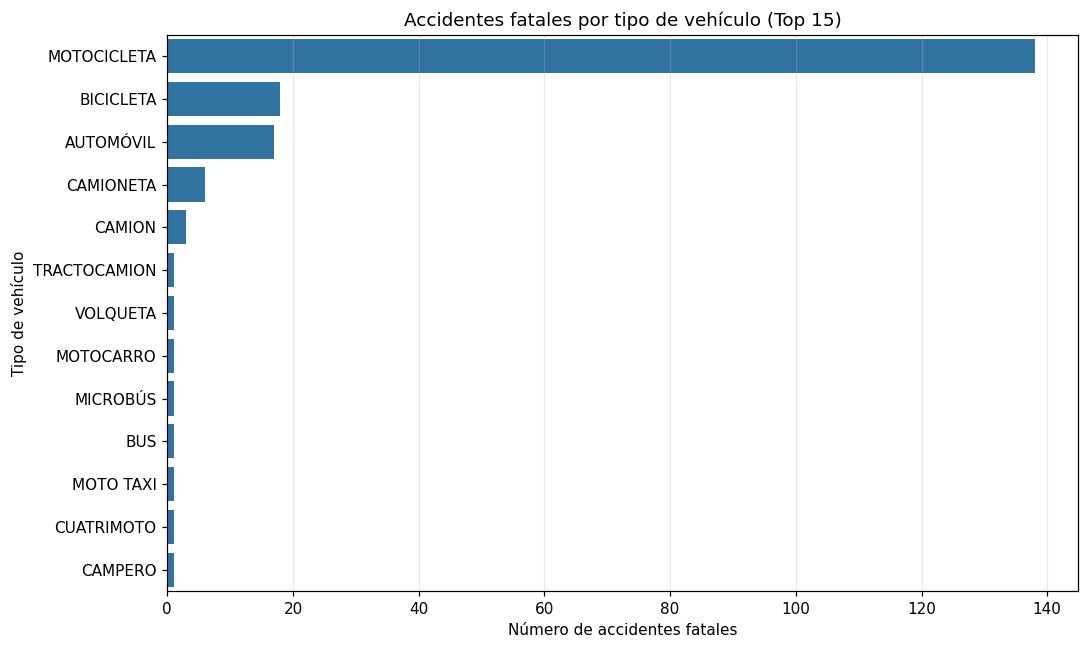

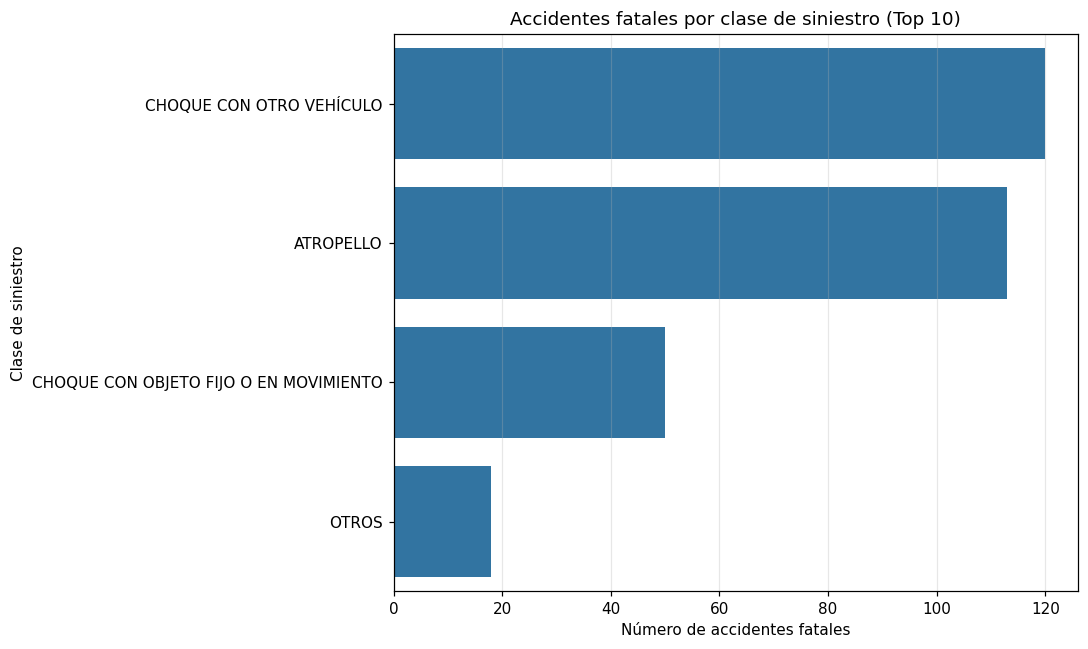

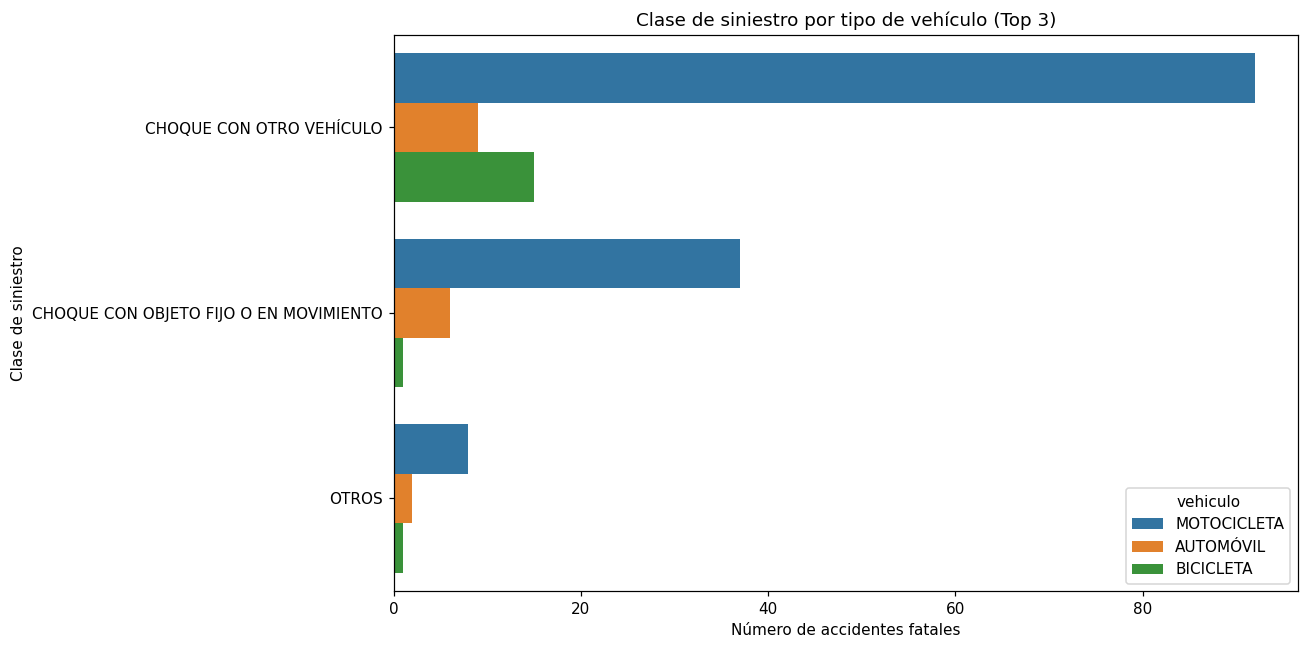

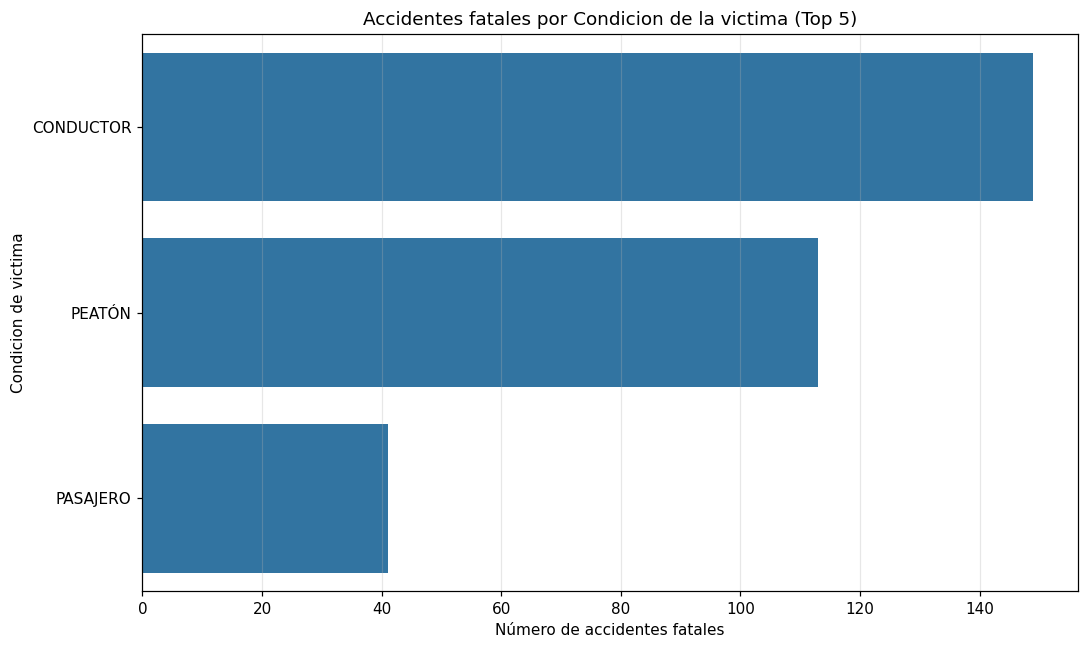

In [7]:
eda = EDA(df_clean)

eda.missing_top()
eda.plot_hour()
eda.plot_vehicle_top(top_n=15)
eda.plot_siniestro_top(top_n=10)
eda.plot_siniestro_by_vehicle(top_veh=3)
eda.plot_Vitima_top(top_n=5)


## 5) Mapa (Folium)

In [8]:
mapper = MapVisualizer(df_clean, lat_col="latitude", lon_col="longitude")
m = mapper.create_map("mapa_accidentes.html")


🗺️ Mapa guardado en: mapa_accidentes.html


## 6) Modelo predictivo (Random Forest)

Objetivo: `clase_de_siniestro` (multiclase).

In [9]:
loader = DataLoader(FILE_PATH, "BASE")
df = loader.load()

cleaner = DataCleaner(df).clean_types().build_time_features().clean_target_classes("clase_de_siniestro")
df_clean = cleaner.get_df()


# Modelo
model = PredictiveModel(df_clean, target="clase_de_siniestro", min_samples_per_class=5)
trained_model = model.train()

✅ Dataset cargado: 304 filas, 51 columnas
📌 Clases usadas en el modelo:
clase_de_siniestro
CHOQUE CON OTRO VEHÍCULO                  120
ATROPELLO                                 113
CHOQUE CON OBJETO FIJO O EN MOVIMIENTO     50
OTROS                                      18
Name: count, dtype: int64

📊 Reporte de clasificación:
                                        precision    recall  f1-score   support

                             ATROPELLO       0.79      0.68      0.73        28
CHOQUE CON OBJETO FIJO O EN MOVIMIENTO       1.00      1.00      1.00        13
              CHOQUE CON OTRO VEHÍCULO       0.74      0.97      0.84        30
                                 OTROS       0.00      0.00      0.00         5

                              accuracy                           0.80        76
                             macro avg       0.63      0.66      0.64        76
                          weighted avg       0.76      0.80      0.77        76

🎯 F1 macro: 0.6428372352285

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
import sys
!{sys.executable} -m pip install streamlit

In [11]:
df.columns

Index(['id', 'regional', 'seccional', 'unidad_basica',
       'departamento_de_atencion', 'municipio_de_atencion',
       'numero_de_radicado', 'tipo_de_caso', 'sexo', 'edad_calculada_en_anos',
       'rango_de_edad', 'unidad_de_edad', 'menor-mayor_de_edad',
       'estado_conyugal', 'nivel_academico', 'pais_de_nacimiento',
       'departamento_de_nacimiento', 'municipio_de_nacimiento',
       'ancestro_racial', 'pertenencia_grupal', 'fecha_del_hecho',
       'fecha_de_los_hechos(reporte)', 'se_conoce_hora_del_hecho',
       'hora_del_hecho', 'hora_de_los_hechos(reporte)', 'rango_hora_del_hecho',
       'presunto_agresor', 'pais_del_hecho', 'departamento_del_hecho',
       'municipio_del_hecho', 'barrio_del_hecho', 'direccion_del_hecho',
       'direccion_completa', 'latitude', 'longitude', 'localidad_del_hecho',
       'zona_del_hecho', 'circunstancia_del_hecho',
       'circunstancia_del_hecho_recodificada', 'escenario_del_hecho',
       'manera_de_muerte_definitiva', 'causa_de_muert

In [12]:
#df.to_csv("accidentes_pereira.csv", index=False, sep=",")

Registros peatón: 113


,edad_calculada_en_anos
count,113.000000
mean,62.707965
std,17.701736
min,3.000000
25%,50.000000
50%,65.000000
75%,77.000000
max,91.000000


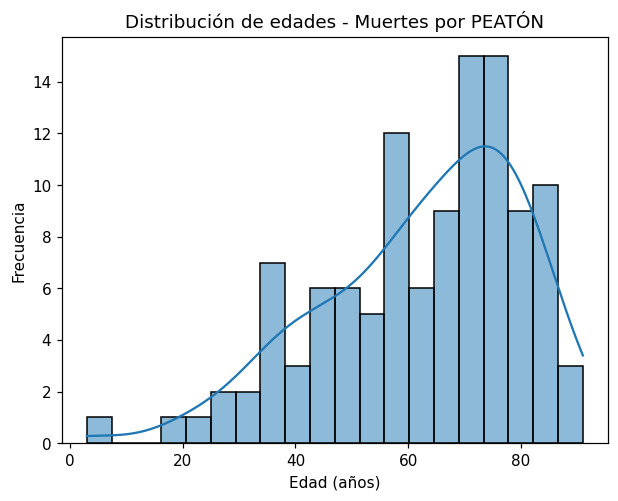

In [15]:
# --- Filtro peatón ---
df_peaton = df[df["condicion_de_la_victima"].fillna("").str.contains("PEATÓN", na=False)].copy()

# Resumen estadístico de edad
print("Registros peatón:", len(df_peaton))
display(df_peaton["edad_calculada_en_anos"].describe())

# Distribución de edades (histograma)
plt.figure()
sns.histplot(df_peaton["edad_calculada_en_anos"].dropna(), bins=20, kde=True)
plt.title("Distribución de edades - Muertes por PEATÓN")
plt.xlabel("Edad (años)")
plt.ylabel("Frecuencia")
plt.show()

# Comparación por año (si existe 'anio')
if "anio" in df_peaton.columns:
    plt.figure()
    sns.boxplot(data=df_peaton, x="anio", y="edad_calculada_en_anos")
    plt.title("Edades de muertes por PEATÓN (Boxplot por año)")
    plt.xlabel("Año")
    plt.ylabel("Edad (años)")
    plt.show()

    # Tabla comparativa por año
    tabla_edad_peaton = (df_peaton
                         .groupby("anio")["edad_calculada_en_anos"]
                         .agg(n="count", media="mean", mediana="median", min="min", max="max")
                         .round(2)
                         .sort_index())
    display(tabla_edad_peaton)

Columnas disponibles (relevantes):
 - vehiculo: ✅
 - hora_de_los_hechos(reporte): ✅
 - hora_reporte: ✅
 - fecha_del_hecho: ✅
 - anio: ✅

Registros moto: 139
Nulos en hora_reporte (moto): 81


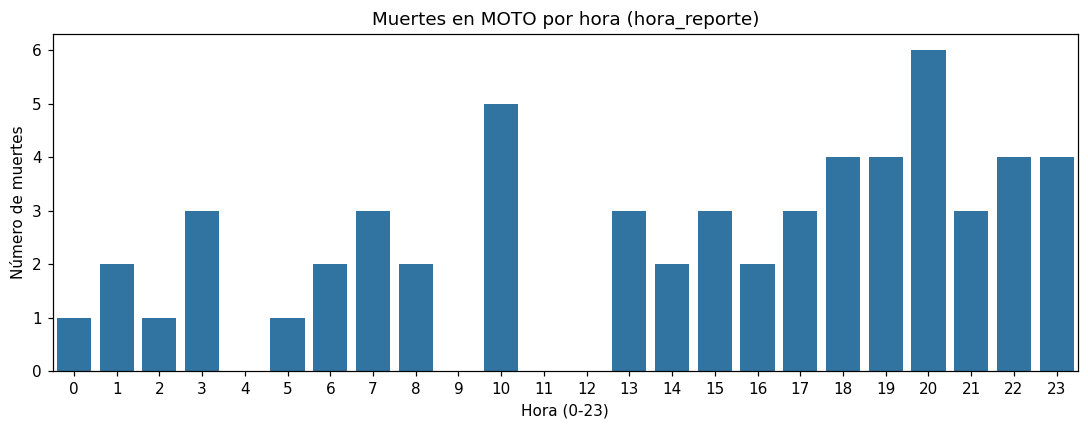

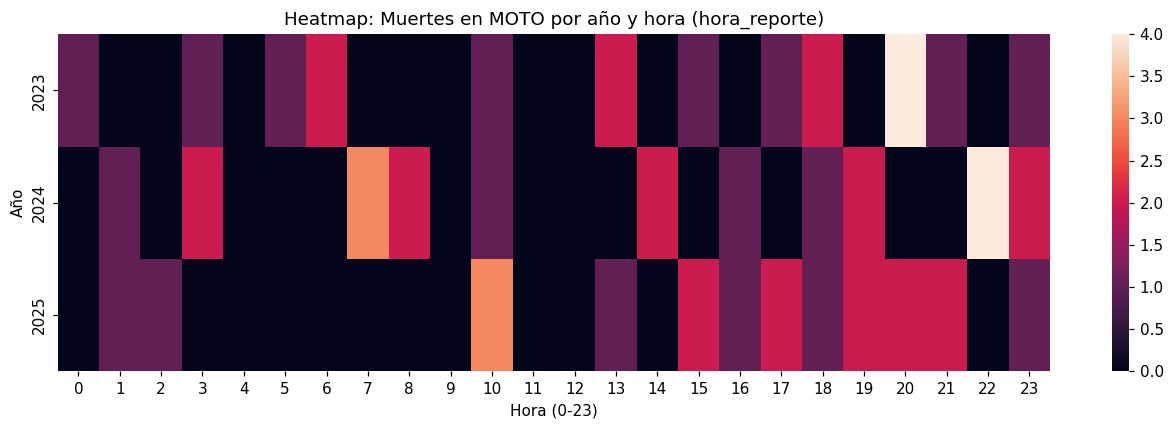

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Asegúrate de usar df_clean (no df)
df_work = df_clean.copy()

# 1) Verifica que existan las columnas necesarias
print("Columnas disponibles (relevantes):")
for c in ["vehiculo", "hora_de_los_hechos(reporte)", "hora_reporte", "fecha_del_hecho", "anio"]:
    print(f" - {c}: {'✅' if c in df_work.columns else '❌'}")

# 2) Filtro de MOTO robusto (evita falsos vacíos)
#    Nota: en tu limpieza, 'vehiculo' quedó en MAYÚSCULAS.
df_moto = df_work[
    df_work["vehiculo"].fillna("").str.contains(r"\bMOTO\b|MOTOCICLETA", regex=True, na=False)
].copy()

print("\nRegistros moto:", len(df_moto))
if len(df_moto) == 0:
    print("\n⚠️ df_moto está vacío. Mira los valores más comunes de 'vehiculo':")
    display(df_work["vehiculo"].value_counts().head(30))
else:
    # 3) Garantiza que haya hora numérica 0-23 (usa hora_reporte)
    #    Si por alguna razón no existe, intenta crearla otra vez desde la columna original.
    if "hora_reporte" not in df_moto.columns or df_moto["hora_reporte"].isna().all():
        if "hora_de_los_hechos(reporte)" in df_moto.columns:
            s = df_moto["hora_de_los_hechos(reporte)"].astype("string").str.strip()
            dt1 = pd.to_datetime(s, format="%H:%M:%S", errors="coerce")
            dt2 = pd.to_datetime(s, format="%H:%M", errors="coerce")
            df_moto["hora_reporte"] = dt1.fillna(dt2).dt.hour

    df_moto["hora_reporte"] = pd.to_numeric(df_moto["hora_reporte"], errors="coerce")

    print("Nulos en hora_reporte (moto):", df_moto["hora_reporte"].isna().sum())
    if df_moto["hora_reporte"].notna().sum() == 0:
        print("\n⚠️ No hay horas válidas para moto. Revisa ejemplos crudos de la columna original:")
        if "hora_de_los_hechos(reporte)" in df_moto.columns:
            display(df_moto["hora_de_los_hechos(reporte)"].head(20))
    else:
        # 4) Conteo por hora (0-23) y gráfica
        conteo = (df_moto.dropna(subset=["hora_reporte"])
                        .groupby("hora_reporte").size()
                        .reindex(range(24), fill_value=0))

        plt.figure(figsize=(10,4))
        sns.barplot(x=conteo.index, y=conteo.values)
        plt.title("Muertes en MOTO por hora (hora_reporte)")
        plt.xlabel("Hora (0-23)")
        plt.ylabel("Número de muertes")
        plt.xticks(range(24))
        plt.tight_layout()
        plt.show()

        # (Opcional) Heatmap por año si existe
        if "anio" in df_moto.columns:
            heat = (df_moto.dropna(subset=["hora_reporte"])
                          .pivot_table(index="anio", columns="hora_reporte", values="vehiculo",
                                       aggfunc="count", fill_value=0)
                          .reindex(columns=range(24), fill_value=0))

            plt.figure(figsize=(12,4))
            sns.heatmap(heat, annot=False)
            plt.title("Heatmap: Muertes en MOTO por año y hora (hora_reporte)")
            plt.xlabel("Hora (0-23)")
            plt.ylabel("Año")
            plt.tight_layout()
            plt.show()

In [23]:
def create_map_layers(
    df,
    output_html="mapa_capas.html",
    lat_col="latitude",
    lon_col="longitude",
    decimals=5,
    min_radius=4,
    max_radius=28,
    scale="sqrt",
    zoom_start=13
):
    df = df.copy()

    # 1) limpiar lat/lon
    df = df.dropna(subset=[lat_col, lon_col])
    df = df[(df[lat_col].between(-90, 90)) & (df[lon_col].between(-180, 180))]

    # 2) definir filtros (capas)
    df_peaton = df[df["condicion_de_la_victima"].fillna("").str.contains("PEATÓN", na=False)].copy()
    df_moto   = df[df["vehiculo"].fillna("").str.contains(r"\bMOTO\b|MOTOCICLETA", regex=True, na=False)].copy()

    # 3) centro del mapa (usa todo)
    center_lat = df[lat_col].mean()
    center_lon = df[lon_col].mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=zoom_start, control_scale=True)

    # 4) función interna para pintar una capa
    def add_layer(df_layer, layer_name, color):
        if len(df_layer) == 0:
            print(f"⚠️ Capa vacía: {layer_name}")
            return

        d = df_layer.copy()
        d["_lat_r"] = d[lat_col].round(decimals)
        d["_lon_r"] = d[lon_col].round(decimals)

        grouped = (
            d.groupby(["_lat_r", "_lon_r"])
             .size()
             .reset_index(name="accidentes")
             .rename(columns={"_lat_r": "lat", "_lon_r": "lon"})
        )

        counts = grouped["accidentes"].to_numpy()
        cmin, cmax = counts.min(), counts.max()

        def radius_from_count(c):
            if cmax == cmin:
                return (min_radius + max_radius) / 2
            if scale == "linear":
                x = (c - cmin) / (cmax - cmin)
            else:
                x = (np.sqrt(c) - np.sqrt(cmin)) / (np.sqrt(cmax) - np.sqrt(cmin))
            return min_radius + x * (max_radius - min_radius)

        fg = folium.FeatureGroup(name=f"{layer_name} ({len(d)} regs)", show=True)

        for _, r in grouped.iterrows():
            r_count = int(r["accidentes"])
            rad = float(radius_from_count(r_count))

            folium.CircleMarker(
                location=[r["lat"], r["lon"]],
                radius=rad,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.55,
                weight=1,
                tooltip=f"{layer_name} - casos en este punto: {r_count}"
            ).add_to(fg)

        fg.add_to(m)

    # 5) agregar capas
    add_layer(df_peaton, "Muertes PEATÓN", "red")
    add_layer(df_moto,   "Muertes MOTO",   "blue")

    # 6) control de capas
    folium.LayerControl(collapsed=False).add_to(m)

    m.save(output_html)
    print(f"🗺️ Mapa con capas guardado en: {output_html}")
    display(m)
    display(IFrame(output_html, width=1000, height=650))
    return m

# --- úsalo así ---
m_layers = create_map_layers(df_clean, output_html="mapa_filtros_peaton_moto.html")

🗺️ Mapa con capas guardado en: mapa_filtros_peaton_moto.html
